<a href="https://colab.research.google.com/github/project-ccap/project-ccap.github.io/blob/master/2025notebooks/2025_0816cnps2025_to_be_presented.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dell model の PyTorch 実装 Dell モデル修正版，S, P パラメータを調整

- CNPS2025 発表用 CCAP 資料用
- date: 2025_0811
- author: 浅川伸一
- memo: 2025_0721 に上杉さんに質問を受けた,すなわち ccap 提供バージョン
- 無反応や保続,迂言を取り込むためのトライアル


ソフトマックス関数の温度パラメータ $\beta$ の学習，勾配降下法による調整の有無

S, P パラメータの修正については，
1. `exp` : $0 < s,p$   両パラメータとも正にする
2. `sigmoid` $0 < s,p < 1$  両パラメータとも 0 から 1 の間の量とする
3. `mixture`: $0 < s, p < 1$ and $s+p=1$   両パラメータの和が 1 とする
4. `none`: $-\infty < s, p < +\infty$   旧モデル

以下のコードではこれらの計算をしている。



# 前準備

In [1]:
%matplotlib inline
import os
import sys
import numpy as np
#import re

import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import IPython
isColab = 'google.colab' in str(IPython.get_ipython())

import matplotlib.pyplot as plt

try:
    import japanize_matplotlib
except ImportError:
    !pip install japanize_matplotlib
    import japanize_matplotlib

if isColab:
    !pip install --upgrade termcolor==1.1
from termcolor import colored

# 乱数のシードを設定
import random
def init_seed(seed:int=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed=42
init_seed(seed)

# 浮動小数点の表示桁数設定
np.set_printoptions(suppress=False, formatter={'float': '{:6.3f}'.format})
torch.set_printoptions(precision=3)

# 機械イプシロンの設定。ただし現在は Xavier initialization に置き換えたので未使用
#EPSILON = torch.finfo(torch.float32).eps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 25.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=64e7df5fe8c7852038f744472871a4228c66e04b7850db784fc67441b1910e3b
  Stored in directory: /root/.cache/pip/wheels/da/a1/71/b8faeb93276fed10edffcca20746f1ef6f8d9e071eee8425fc
Successfully built japanize_matplotlib
  Preparing metadata (setup.py) ... done
  Created wheel for termcolor: filename=termcolor-1.1.0-py3-none-any.whl size=4832 sha256=708c7a9d0ecae9073e758db300d6403f5ee4727f12939f854d63c61132451454
  Stored in directory: /root/.cache/pip/wheels/9f/ca/d7/8f2399d70f5d641d4fef951a78d6aa4ab64cc582e1c4dec9a3
Successfully built termcolor
  Attempting uninstall: termcolor
    Found existing installation: termcolor 3.1.0
    Uninstalling termcolor-3.1.0:
      Successfully uninstalled termcolor-3.1.0


# S と P の結合係数行列の設定

7 番目の反応カテゴリーを無視する場合 (Foygel&Dell2000 の流儀)，下のセル 27, 28 行目をコメントアウトする必要がある。

In [2]:
#print('#Dell model の項目間 (ニューロン間) 結合を設定: Ws')
Ws = np.array([[1,1,1,1,1,1,1,1,1,1, 0,0,0,0,0,0,0,0,0,0,
                0,0,0,0,0,0,0,0,0,0, 0,0,0,0,0,0,0,0,0,0,
                0,0,0,0,0,0,0,0,0,0, 0,0,0,0],            # cat 正解
               [0,0,0,0,0,0,0,1,1,1, 1,1,1,1,1,1,1,0,0,0,
                0,0,0,0,0,0,0,0,0,0, 0,0,0,0,0,0,0,0,0,0,
                0,0,0,0,0,0,0,0,0,0, 0,0,0,0],            # dog 意味エラー
               [0,0,0,0,0,0,0,0,0,0, 0,0,0,0,0,0,0,1,1,1,
                1,1,1,1,1,1,1,0,0,0, 0,0,0,0,0,0,0,0,0,0,
                0,0,0,0,0,0,0,0,0,0, 0,0,0,0],            # mat 形態エラー
               [0,0,0,0,0,0,0,1,1,1, 0,0,0,0,0,0,0,0,0,0,
                0,0,0,0,0,0,0,1,1,1, 1,1,1,1,0,0,0,0,0,0,
                0,0,0,0,0,0,0,0,0,0, 0,0,0,0],            # rat 混合エラー
               [0,0,0,0,0,0,0,0,0,0, 0,0,0,0,0,0,0,0,0,0,
                0,0,0,0,0,0,0,0,0,0, 0,0,0,0,1,1,1,1,1,1,
                1,1,1,1,0,0,0,0,0,0, 0,0,0,0],            # fog 無関連エラー
               [0,0,0,0,0,0,0,0,0,0, 0,0,0,0,0,0,0,0,0,0,
                0,0,0,0,0,0,0,0,0,0, 0,0,0,0,0,0,0,0,0,0,
                0,0,0,0,1,1,1,1,1,1, 1,1,1,1],            # lat 非単語
               # [0,0,0,0,0,0,0,0,0,0, 0,0,0,0,0,0,0,0,0,0,
               #  0,0,0,0,0,0,0,0,0,0, 0,0,0,0,0,0,0,0,0,0,
               #  0,0,0,0,0,0,0,0,0,0, 0,0,0,0]             # 無反応,保続,迂言 意味系の関与なしで 0 としている
              ])

# 上の Ws 定義で最後にすべて 0 のリストを加える代わりに乱数を加える
# これは無反応を擬似的に表現している Xavier initializer と等価な初期化。
_rnd = np.random.randn(1,Ws.shape[1]) / np.sqrt(Ws.size)
Ws = np.concatenate([Ws, _rnd], axis=0)

#print('#語彙層と音韻層とを結ぶ結合係数行列の定義: Wp and phonology')
phonology = {'cat': np.array([ 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0]),  # correct
             'dog': np.array([ 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0]),  # semantic error
             'mat': np.array([ 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0]),  # formal error
             'rat': np.array([ 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0]),  # mixed error
             'fog': np.array([ 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0]),  # unrelated error
             'lat': np.array([ 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0]),  # nonword
                               #   f,   r,   d,   k,   m,  ae,   o,   t,   g
             # 'NoRes': np.array([ EPSILON, EPSILON, EPSILON, EPSILON, EPSILON, EPSILON, EPSILON, EPSILON, EPSILON])} # 無反応,迂言,保続
            }
# phonology は BOW 形式なんですなー

# Xavier 初期化
phonology['No_Resp'] = np.random.rand(len(list(phonology.values())[0])) / np.sqrt(len(list(phonology.values())[0]) * len(phonology))
Wp = np.array([phonology[item] for item in phonology])

print('#元データ 意味層と語彙層との間の結合係数行列 Ws:\n', Ws)
print('#元データ 語彙層と音韻層との間の結合係数行列 Wp:\n', Wp)

tags = list(phonology)
print('#相関係数行列 意味入力層<->語彙層 Ws:\n', tags, '\n', np.corrcoef(Ws))
print('#相関係数行列 語彙層<->音韻層 Wp:\n', tags, '\n',
      np.corrcoef(np.array([phonology[item] for item in phonology])))

Rp = torch.Tensor(np.corrcoef(Wp)).requires_grad_(False)
print(f'Rp:\n{Rp}')
Rs = torch.Tensor(np.corrcoef(Ws)).requires_grad_(False)
print(f'Rs:\n{Rs}')

#元データ 意味層と語彙層との間の結合係数行列 Ws:
 [[ 1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000
   0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000
   0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000
   0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000
   0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000
   0.000  0.000  0.000  0.000]
 [ 0.000  0.000  0.000  0.000  0.000  0.000  0.000  1.000  1.000  1.000
   1.000  1.000  1.000  1.000  1.000  1.000  1.000  0.000  0.000  0.000
   0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000
   0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000
   0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000
   0.000  0.000  0.000  0.000]
 [ 0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000
   0.000  0.000  0.000  0.000  0.000  0.000  0.000  1.000  1.000  1.000
   1.000  1.000  1.000  1.000  1.000  1.000  

# Dell モデルのサンプルデータ定義

In [3]:
Dell_control = torch.tensor([0.9690, 0.0120, 0.0010, 0.0090, 0.0030, 0.0000])  # (s,f) =(0.0698, 0.1000)
Dell_LH = torch.tensor([0.69, 0.03, 0.07, 0.15, 0.01, 0.02])  # Conduction aphasia
Dell_IG = torch.tensor([0.69, 0.09, 0.05, 0.02, 0.03, 0.01])  # Anomic

# 総和が 1 になることを確認するために印字
for _dell_model in [Dell_control, Dell_LH, Dell_IG]:
    _sum = _dell_model.sum()

    # 1 から各症例データの総和を引くことで others を求め最後尾に追加
    _dell_model = torch.cat((_dell_model, torch.tensor([1-_sum])))
    print(_dell_model.sum(), _dell_model)

tensor(1.) tensor([0.969, 0.012, 0.001, 0.009, 0.003, 0.000, 0.006])
tensor(1.) tensor([0.690, 0.030, 0.070, 0.150, 0.010, 0.020, 0.030])
tensor(1.000) tensor([0.690, 0.090, 0.050, 0.020, 0.030, 0.010, 0.110])


# Foygel&Dell2000 データの定義

In [6]:
# Foygel & Dell 2000 Table 2.
FoygelDell_tab2={
    #Table 2 に記載のデータ。小数点以下４桁目が必要なのか疑問。理由は PNT の検査図版は 175 枚しかない。
    #どんなに努力しても一回の検査で得られるデータは 175 しかないのだから，小数点以下 2 桁で十分ではないかなー
    #各行のデータ，最後の 4 列は weight, decay と s, f パラメータの推定値を表す.
    #ただし s, f は table 4 より引用
    'W.B_Wernicke':  [0.9400,0.0200,0.0100,0.0100,0.0100,0.0000,0.0200,0.5600, 0.0352, 0.0274],
    'T.T._Anomic': [0.9300,0.0100,0.0100,0.0000,0.0200,0.0000,0.0200,0.5600, 0.0340, 0.0866],
    'J.Fr._Wernicke':[0.9200,0.0100,0.0100,0.0200,0.0200,0.0000,0.0200,0.5600, 0.0316, 0.0305],
    'V.C._Anomic': [0.8700,0.0200,0.0100,0.0300,0.0100,0.0000,0.0200,0.5700, 0.0407, 0.0229],
    'L.B._Anomic': [0.8200,0.0400,0.0200,0.0900,0.0100,0.0100,0.0070,0.5000, 0.0274, 0.0221],
    'J.B._Conduction': [0.7600,0.0600,0.0100,0.0500,0.0200,0.0100,0.0065,0.5000, 0.0264, 0.0246],
    'J.L._Conduction': [0.7600,0.0300,0.0100,0.0600,0.0300,0.0100,0.0250,0.6000, 0.0255, 0.0221],
    'G.S._Wernicke': [0.7000,0.0200,0.0600,0.1500,0.0100,0.0200,0.0057,0.5000, 0.0246, 0.0191],
    'L.H._Conduction': [0.6900,0.0300,0.0700,0.1500,0.0100,0.0200,0.0057,0.5000, 0.0237, 0.0178],
    'J.G._Conduction': [0.5500,0.0600,0.0800,0.1800,0.0400,0.0300,0.0450,0.7000, 0.0191, 0.0172],
    'E.G._Anomic': [0.9300,0.0300,0.0000,0.0100,0.0200,0.0000,0.1000,0.6000, 0.0316, 0.0305],
    'B.Me._Anomic':[0.8400,0.0300,0.0100,0.0000,0.0500,0.0100,0.1000,0.8200, 0.0165, 0.0866],
    'B.Mi._Anomic':[0.8300,0.0500,0.0100,0.0100,0.0200,0.0100,0.0550,0.7000, 0.0255, 0.0328],
    'J.A._Transcortical Sensory': [0.7800,0.0400,0.0000,0.0200,0.0300,0.0100,0.0580,0.7000, 0.0246, 0.0294],
    'A.F._Wernicke': [0.7500,0.0200,0.0300,0.0700,0.0600,0.0400,0.1000,0.8500, 0.0205, 0.0229],
    'N.C._Conduction': [0.7500,0.0300,0.0700,0.0800,0.0100,0.0000,0.1000,0.8500, 0.0237, 0.0221],
    'I.G._Anomic': [0.6900,0.0900,0.0500,0.0200,0.0300,0.0100,0.1000,0.8600, 0.0198, 0.0340],
    'H.B._Conduction': [0.6100,0.0600,0.1300,0.1800,0.0200,0.0100,0.0500,0.7130, 0.0191, 0.0172],
    'J.F._Anomic': [0.5600,0.1400,0.0100,0.0200,0.1100,0.0100,0.1000,0.8600, 0.0107, 0.0365],
    'G.L._Wernicke': [0.2800,0.0400,0.2100,0.3000,0.0300,0.0900,0.0790,0.8500, 0.0093, 0.0154],
    'W.R._Wernicke': [0.0800,0.0600,0.1500,0.2800,0.0500,0.3300,0.1000,0.9400, 0.0010, 0.0178]
    #                 Correct, Semantic, Formal, Nonword, Mixed, Unrelated, W, D, S, P
}

# 上の FoygelDell_tab2 から必要な情報だけを切り取って印字。症例 H．B． だけ総和が 1 を超えるダメだデータ
# 1997 年の時点で違っている。しかも後年の関連論文で誤りを修正していない。こいつら真性の馬鹿なのかもな。
for k, v in FoygelDell_tab2.items():
    data = np.array(v[:6])
    _sum = data.sum()
    _other = 1 -_sum
    data = np.append(data, _other)

    color = 'red' if _sum > 1 else 'grey'
    attrs = 'bold' if _sum > 1 else 'blink'
    print(colored(f'{k:26s} {_sum:.3f} {data} (s,p):{v[-2:]}', color=color, attrs=[attrs]))

W.B_Wernicke               0.990 [ 0.940  0.020  0.010  0.010  0.010  0.000  0.010] (s,p):[0.0352, 0.0274]
T.T._Anomic                0.970 [ 0.930  0.010  0.010  0.000  0.020  0.000  0.030] (s,p):[0.034, 0.0866]
J.Fr._Wernicke             0.980 [ 0.920  0.010  0.010  0.020  0.020  0.000  0.020] (s,p):[0.0316, 0.0305]
V.C._Anomic                0.940 [ 0.870  0.020  0.010  0.030  0.010  0.000  0.060] (s,p):[0.0407, 0.0229]
L.B._Anomic                0.990 [ 0.820  0.040  0.020  0.090  0.010  0.010  0.010] (s,p):[0.0274, 0.0221]
J.B._Conduction            0.910 [ 0.760  0.060  0.010  0.050  0.020  0.010  0.090] (s,p):[0.0264, 0.0246]
J.L._Conduction            0.900 [ 0.760  0.030  0.010  0.060  0.030  0.010  0.100] (s,p):[0.0255, 0.0221]
G.S._Wernicke              0.960 [ 0.700  0.020  0.060  0.150  0.010  0.020  0.040] (s,p):[0.0246, 0.0191]
L.H._Conduction            0.970 [ 0.690  0.030  0.070  0.150  0.010  0.020  0.030] (s,p):[0.0237, 0.0178]
J.G._Conduction            0.940 [ 0.5

<!-- <img src="1997Dell_tab6.svg" width="77%"> -->

原著論文のデータ
Dell et. al (1997) Table 6.<br/>
<img src="https://raw.githubusercontent.com/ShinAsakawa/ShinAsakawa.github.io/refs/heads/master/2025figures/1997Dell_tab6.svg" width="49%;">

## 下請け関数 交差エントロピーと softmax 関数の定義

In [7]:
def my_CrossEntropy(t, p, epsilon=10 ** -7):
    """交差エントロピー"""
    ce = t * torch.log(p) + (1-t) * torch.log(1-t)
    return -ce.sum()

def my_softmax(x, beta=1., is_beta_param=True):
    """ソフトマックス関数 に温度パラメータを付加したバージョン"""
    if isinstance(x, list):
        x = torch.Tensor(x)
    elif isinstance(x, np.ndarray):
        x = torch.Tensor(x)
    bias = (x * beta).mean()

    if is_beta_param:
        return torch.exp(x * beta - bias) / torch.exp(x * beta - bias).sum()
    else:
        return torch.exp(x - bias) / torch.exp(x - bias).sum()

# モデルX の定義

In [8]:
class Dell_model0(nn.Module):
    """Dell model 零号機
    このモデルを修正することで勾配降下法の local minima を回避するアルゴリズムにする。
    """
    def __init__(self, Rs, Rp):
        super().__init__()
        self.Rs = Rs      #意味層と語彙層との間の結合係数
        self.Rp = Rp      #語彙層と音韻層との間の結合係数

        # self.theta_s = nn.Parameter(torch.randn(1))  #Dell の s パラメータ
        # self.theta_p = nn.Parameter(torch.randn(1))  #Dell の p パラメータ

        self.theta_s = nn.Parameter(torch.rand(1))  #Dell の s パラメータ
        self.theta_p = nn.Parameter(torch.rand(1))  #Dell の p パラメータ
        print(f'Init self.theta_s.data:{self.theta_s.data}',
              f'Iniet self.theta_p.data:{self.theta_p.data}')

        self.sem = torch.zeros(self.Rs.shape[0]).requires_grad_(False)
        self.sem[0] = 1
        self.lex = torch.zeros(self.Rs.shape[0]).requires_grad_(False)
        self.pho = torch.zeros(self.Rp.shape[0]).requires_grad_(False)


        #語彙層のバイアス項 Dell のオリジナルモデルには存在しない
        self.bias_sem = nn.Parameter(torch.zeros(self.Rs.shape[0]))

        #語彙層のバイアス項 Dell のオリジナルモデルには存在しない
        self.bias_lex = nn.Parameter(torch.zeros(self.Rs.shape[0]))

        #音韻層のバイアス項 Dell のオリジナルモデルには存在しない
        self.bias_pho = nn.Parameter(torch.zeros(self.Rp.shape[0]))

        self.beta = nn.Parameter(torch.tensor([1.]))  #ソフトマックス関数の温度パラメータ
        self.a = nn.Tanh()                            #ハイパータンジェント関数を活性化関数として採用

    #def forward(self, inp):
    def forward(self):
        """前向きの処理"""
        self.sem = self.a(self.lex @ (self.Rs * self.theta_s) + self.bias_sem)
        #self.lex = self.a(self.inp @ (self.Rs * self.theta_s) + self.bias_lex)

        # 語彙層は意味層と音韻層との両者から入力を受け取るので,上杉さんの指摘により変更 2025_0723
        self.lex = self.a(self.sem @ (self.Rs * self.theta_s + self.Rp * self.theta_p) + self.bias_lex)
        # self.lex = self.a(self.sem @ (self.Rs * self.theta_s) + self.bias_lex) こちらは旧版
        self.pho = self.a(self.lex @ (self.Rp * self.theta_p) + self.bias_pho)
        return my_softmax(self.pho, beta=self.beta)


class Dell_modelX(nn.Module):
    """Dell model 普及機 (初号機，弐号機, 参号機)
    s, p を sigmoid(), または exp() に変換して強制的に 0 < s, p, または 0 < s, p < 1 に変換する
    """
    def __init__(self,
                 Rs:torch.Tensor,
                 Rp:torch.Tensor,
                 out_f:str='None',  # ['none', 'exp', 'sigmoid']
                 is_beta_param:bool=True
                ):
        super().__init__()
        self.Rs = Rs      #意味層と語彙層との間の結合係数
        self.Rp = Rp      #語彙層と音韻層との間の結合係数

        self.linS = torch.nn.Linear(in_features=Rs.numel(), out_features=1, bias=True)
        self.linP = torch.nn.Linear(in_features=Rp.numel(), out_features=1, bias=True)
        self.out_f_name = 'None'
        self.is_beta_param = is_beta_param

        if out_f == 'None':
            self.out_fname = 'None'
            self.theta_s = nn.Parameter(torch.rand(1))  #Dell の s パラメータ
            self.theta_p = nn.Parameter(torch.rand(1))  #Dell の p パラメータ
        elif out_f == 'exp':  # 初号機に相当
            self.out_fname = 'exp'
            self.out_f = torch.exp
        elif out_f == 'sigmoid':
            self.out_fname = 'sigmoid'
            self.out_f = torch.sigmoid
        elif out_f == 'mixture':
            self.out_fname = 'mixture'
            self.out_f = torch.exp
        else:
            raise ValueError(f'不正な出力層の活性化関数: {out_f}')

        if out_f != 'None':
            self.theta_s = self.out_f(self.linS(Rs.flatten()))
            self.theta_p = self.out_f(self.linP(Rp.flatten()))
        elif out_f == 'mixture':
            self.theta_s = self.theta_s / (self.theta_s + self.theta_p)
            self.theta_p = 1.0 - self.theta_s

        print(f'Initial values of parameters estimated, self.theta_s:{self.theta_s.detach().numpy()}',
              f'self.theta_p:{self.theta_p.detach().numpy()}')

        self.sem = torch.zeros(self.Rs.shape[0]).requires_grad_(False)
        self.sem[0] = 1
        self.lex = torch.zeros(self.Rs.shape[0]).requires_grad_(False)
        self.pho = torch.zeros(self.Rp.shape[0]).requires_grad_(False)


        #語彙層のバイアス項 Dell のオリジナルモデルには存在しない
        self.bias_sem = nn.Parameter(torch.zeros(self.Rs.shape[0]))

        #語彙層のバイアス項 Dell のオリジナルモデルには存在しない
        self.bias_lex = nn.Parameter(torch.zeros(self.Rs.shape[0]))

        #音韻層のバイアス項 Dell のオリジナルモデルには存在しない
        self.bias_pho = nn.Parameter(torch.zeros(self.Rp.shape[0]))

        self.beta = nn.Parameter(torch.tensor([1.]))  #ソフトマックス関数の温度パラメータ
        self.a = nn.Tanh()                            #ハイパータンジェント関数を活性化関数として採用

    def forward(self):
        """前向きの処理"""
        if self.out_fname != 'None':
            self.theta_s = self.out_f(self.linS(Rs.flatten()))
            self.theta_p = self.out_f(self.linP(Rp.flatten()))

        if self.out_fname == 'mixture':
            self.theta_s = self.theta_s / (self.theta_s + self.theta_p)
            self.theta_p = 1.0 - self.theta_s

        self.sem = self.a(self.lex @ (self.Rs * self.theta_s) + self.bias_sem)

        # 語彙層は意味層と音韻層との両者から入力を受け取るので,上杉さんの指摘により変更 2025_0723
        self.lex = self.a(self.sem @ (self.Rs * self.theta_s + self.Rp * self.theta_p) + self.bias_lex)
        self.pho = self.a(self.lex @ (self.Rp * self.theta_p) + self.bias_pho)
        return my_softmax(self.pho, beta=self.beta, is_beta_param=self.is_beta_param)


# 全シミュレーション条件を訓練する関数 train_dell() 関数の定義

In [9]:
def train_dell(target,                 # 各カテゴリに対する反応確率 たとえば Dell_control=[0.969, 0.012, 0.001, 0.009, 0.003, 0.000]
               model,                  # 学習させる対象のモデル， Dell_modelX または Dell_model0
               iter_max=10 ** 3,       # 訓練の反復回数
               lr=1e-1,                # 学習率
               loss_f=my_CrossEntropy, # 損失関数 交差エントロピーを仮定。
               Rp=Rp,                  # 音韻結合強度
               Rs=Rs,                  # 意味結合強度
               out_f='None',           # 出力関数 モデルによって None, 'exp', 'sigmoid', 'mixture' のいずれかをとる
               verbose=False):         # 冗長出力のためのフラグ

    interval = iter_max * 10 ** -1

    for tau in range(iter_max):                # iter_max 回の繰り返し
        y_hat = model()                        # 入力層へ Sem を与えて，出力値の予測値 y_hat を得る
        loss = loss_f(target, y_hat)           # 直上行で得られた y_hat と予測すべき値 (患者から得れた値など) とから損失値を得る
        loss.backward(retain_graph=True)
        with torch.no_grad():                  # 学習
            for param in model.parameters():   # モデルへのフィッティング，パラメータの更新
                param -= lr * param.grad
            model.zero_grad()
        if tau % interval == 0 and verbose:       #途中経過の印字
            beta = model.beta.detach().numpy()[0]
            s = model.theta_s.detach().numpy()[0]
            p = model.theta_p.detach().numpy()[0]
            print(f'{tau:05d} loss:{loss:.3f} beta:{1./beta:5.3f} s:{s:5.3f} p:{p:5.3f}',
                  f'y_hat:{y_hat.detach().numpy()}' )

    # 最終結果を返す
    beta = model.beta.detach().numpy()[0]
    s = model.theta_s.detach().numpy()[0]
    p = model.theta_p.detach().numpy()[0]
    params = {'beta':beta, 's':s, 'p':p}
    return y_hat.detach().numpy(), [1/beta, s, p]

# Foygel&Dell2000 の control, LH, IG データを用いたパラメータ推定

In [ ]:
%%time
# 直上セルで定義した `train_dell()` を用いて Dell 症例データを学習させる。

# train_dell() 関数に与える引数の値を設定
verbose=True
out_f = 'exp'
out_f = 'sigmoid'
out_f = 'mixture'
#out_f = 'None'
is_beta_param = True
lr = 1e-1
iter_max = 1 * 10 ** 3

reps = 10   # 10 回反復推定
reps = 2    # for debugging use

# 結果を格納するリスト
Dell_mixture_results = []

for _teach in [Dell_control, Dell_LH, Dell_IG]: # 3 症例 (1 つは健常統制)について繰り返す
    others = torch.tensor([1-_teach.sum()])     # 症例ごとの確率の総和を使って others 条件に対応する値を求める
    _teach = torch.cat((_teach,others))         # others の値を _teach に連結
    print(f'_teach:{_teach}')
    for _ in range(reps):
        _model = Dell_modelX(Rs=Rs, Rp=Rp, out_f=out_f, is_beta_param=is_beta_param)
        #_model = Dell_model0(Rs=Rs, Rp=Rp)
        y_hat, [beta, s, p] = train_dell(target=_teach, model=_model, out_f=out_f, verbose=verbose, lr=lr, iter_max=iter_max)
        print(f'Finale, beta:{beta:.3f}, s:{s:.3f}, p:{p:.3f}, y_hat:{y_hat}')
        Dell_mixture_results.append((beta,s,p,y_hat))

_teach:tensor([0.969, 0.012, 0.001, 0.009, 0.003, 0.000, 0.006])
Initial values of parameters estimated, self.theta_s:[ 1.412] self.theta_p:[ 0.686]
00000 loss:2.084 beta:1.000 s:0.673 p:0.327 y_hat:[ 0.143  0.143  0.143  0.143  0.143  0.143  0.143]
00100 loss:0.341 beta:0.324 s:0.745 p:0.255 y_hat:[ 0.934  0.015  0.009  0.011  0.009  0.009  0.013]
00200 loss:0.327 beta:0.297 s:0.744 p:0.256 y_hat:[ 0.960  0.011  0.004  0.007  0.006  0.004  0.008]
00300 loss:0.324 beta:0.289 s:0.742 p:0.258 y_hat:[ 0.965  0.011  0.003  0.007  0.004  0.003  0.006]
00400 loss:0.323 beta:0.284 s:0.738 p:0.262 y_hat:[ 0.966  0.011  0.003  0.007  0.004  0.003  0.006]
00500 loss:0.323 beta:0.280 s:0.735 p:0.265 y_hat:[ 0.967  0.012  0.002  0.008  0.004  0.002  0.006]


# Dell 3 症例の結果描画

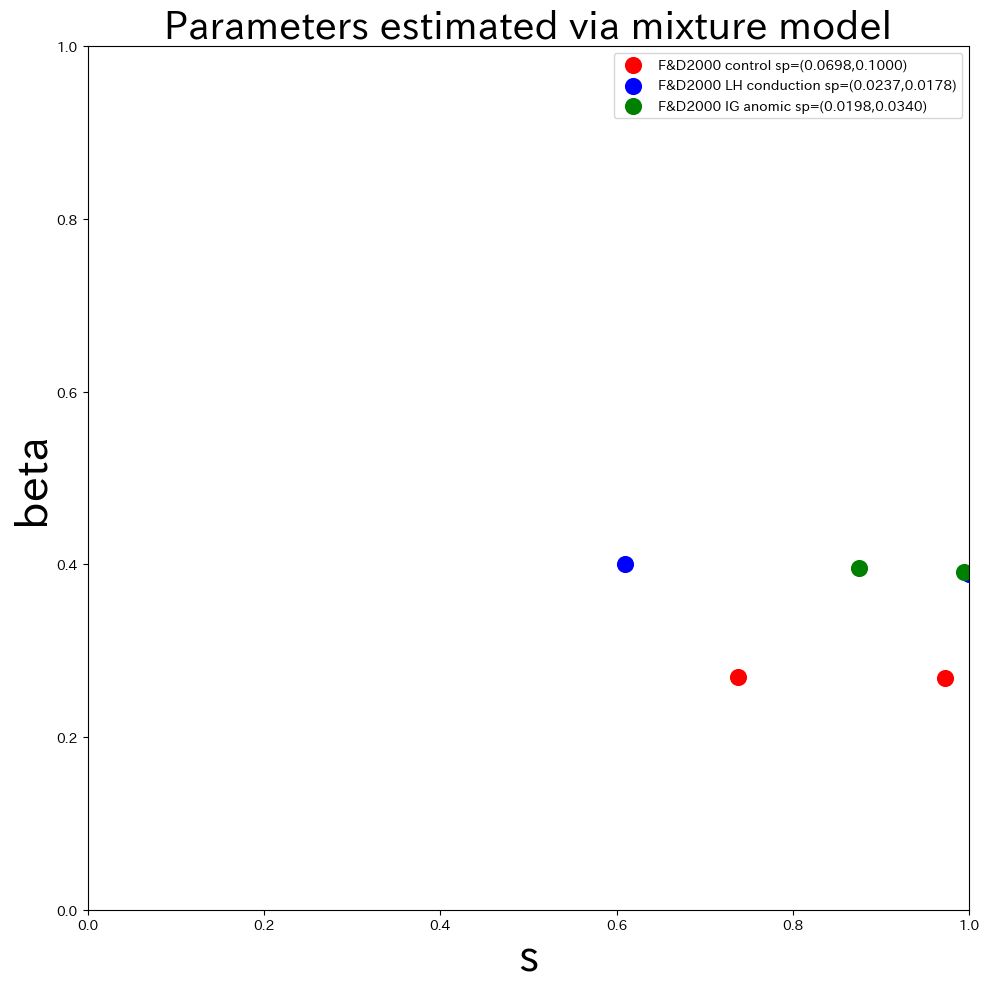

In [ ]:
# 結果の描画
Dell_res = [{'beta':[], 's':[], 'p':[]},{'beta':[],'s':[],'p':[]},{'beta':[], 's':[],'p':[]}]
for i, (beta, s, p, y_hat) in enumerate(Dell_mixture_results):
    ii = i // reps
    Dell_res[ii]['beta'].append(beta)
    Dell_res[ii]['s'].append(s)
    Dell_res[ii]['p'].append(p)

import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib

dell_colors = ['red', 'blue', 'green']
dell_labels = ['F&D2000 control sp=(0.0698,0.1000)', 'F&D2000 LH conduction sp=(0.0237,0.0178)', 'F&D2000 IG anomic sp=(0.0198,0.0340)']


Dell_C = []
for x in Dell_res:
    for i, j in zip(x['s'], x['beta']):
        Dell_C.append(np.array((i,j)))
Dell_C = np.array(Dell_C)

plt.figure(figsize=(10,10))
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('s', fontsize=32)
plt.ylabel('beta', fontsize=32)
plt.title('Parameters estimated via mixture model', fontsize=28)

for i in range(3):
    Dell_Z = Dell_C[i*reps:i*reps+reps]
    plt.scatter(Dell_Z[:,0], Dell_Z[:,1], color=dell_colors[i],label=dell_labels[i],s=128)

plt.legend()
plt.tight_layout()
plt.show()


# 大門2024 6 症例のパラメータ推定

In [ ]:
%%time
# 2025_0804 大門先生から送られてきたデータ
Daimon2024 = {'svPPA':  torch.Tensor([ 51, 16,  0,  0, 0,  0, 135]),
              'HSVE':   torch.Tensor([165, 38,  0,  0, 2,  0,   3]),
              'SY_IFG': torch.Tensor([115, 34,  0,  0, 2,  0,  53]),
              'HM_IFG': torch.Tensor([135, 54,  0,  0, 4,  0,  27]),
              'YT_角回': torch.Tensor([126, 18,  0,  0, 2,  0,   62]),
              'MR_pMLG':torch.Tensor([175,  32,  0,  0, 0,  0,   7])}
              #                      正解,意味性,形態性,混合性,無関連,非単語,その他(無反応，保続,音断片,新造語,迂言)
_Daimon2024 = [v/v.sum() for k, v in Daimon2024.items()]

verbose=True
out_f = 'exp'
out_f = 'sigmoid'
out_f = 'mixture'
#out_f = 'None'
is_beta_param = True
lr = 1e-1
iter_max = 1 * 10 ** 3
reps = 2

daimon_mixture_results = []
for _teach in _Daimon2024:
    print(f'_teach:{_teach}')
    for _ in range(reps):
        _model = Dell_modelX(Rs=Rs, Rp=Rp, out_f=out_f, is_beta_param=is_beta_param)
        #_model = Dell_model0(Rs=Rs, Rp=Rp)
        y_hat, [beta, s, p] = train_dell(target=_teach, model=_model, out_f=out_f, verbose=verbose, lr=lr, iter_max=iter_max)
        print(f'Finale, beta:{beta:.3f}, s:{s:.3f}, p:{p:.3f}, y_hat:{y_hat}')
        daimon_mixture_results.append((beta,s,p,y_hat))

_teach:tensor([0.252, 0.079, 0.000, 0.000, 0.000, 0.000, 0.668])
Initial values of parameters estimated, self.theta_s:[ 0.785] self.theta_p:[ 0.926]
00000 loss:2.605 beta:1.000 s:0.459 p:0.541 y_hat:[ 0.143  0.143  0.143  0.143  0.143  0.143  0.143]
00100 loss:1.516 beta:0.394 s:0.180 p:0.820 y_hat:[ 0.237  0.075  0.010  0.008  0.012  0.008  0.649]
00200 loss:1.494 beta:0.344 s:0.142 p:0.858 y_hat:[ 0.247  0.078  0.004  0.004  0.005  0.004  0.658]
00300 loss:1.488 beta:0.321 s:0.124 p:0.876 y_hat:[ 0.249  0.078  0.003  0.002  0.003  0.002  0.661]
00400 loss:1.485 beta:0.306 s:0.113 p:0.887 y_hat:[ 0.250  0.079  0.002  0.002  0.003  0.002  0.663]
00500 loss:1.483 beta:0.296 s:0.106 p:0.894 y_hat:[ 0.251  0.079  0.002  0.001  0.002  0.001  0.664]
00600 loss:1.482 beta:0.288 s:0.101 p:0.899 y_hat:[ 0.251  0.079  0.001  0.001  0.002  0.001  0.665]
00700 loss:1.481 beta:0.282 s:0.097 p:0.903 y_hat:[ 0.251  0.079  0.001  0.001  0.001  0.001  0.665]
00800 loss:1.481 beta:0.276 s:0.094 p:0.906

In [ ]:
# _Daimon2024 = [v/v.sum() for k, v in Daimon2024.items()]

# print(Daimon2024['HM_IFG'])
# print(_Daimon2024[3])

# verbose=True
# out_f = 'exp'
# out_f = 'sigmoid'
# out_f = 'mixture'
# #out_f = 'None'
# is_beta_param = True
# lr = 1e-1
# iter_max = 1 * 10 ** 3

# _teach = _Daimon2024[3]
# print(f'_teach:{_teach}')
# for _ in range(10):
#     _model = Dell_modelX(Rs=Rs, Rp=Rp, out_f=out_f, is_beta_param=is_beta_param)
#     #_model = Dell_model0(Rs=Rs, Rp=Rp)
#     y_hat, [beta, s, p] = train_dell(target=_teach, model=_model, out_f=out_f, verbose=verbose, lr=lr, iter_max=iter_max)
#     print(f'Finale, beta:{beta:.3f}, s:{s:.3f}, p:{p:.3f}, y_hat:{y_hat}')
# #         daimon_mixture_results.append((beta,s,p,y_hat))


tensor([135.,  54.,   0.,   0.,   4.,   0.,  27.])
tensor([0.614, 0.245, 0.000, 0.000, 0.018, 0.000, 0.123])
_teach:tensor([0.614, 0.245, 0.000, 0.000, 0.018, 0.000, 0.123])
self.theta_s:[ 1.248] self.theta_p:[ 1.014]
00000 loss:2.659 beta:1.000 s:0.552 p:0.448 y_hat:[ 0.143  0.143  0.143  0.143  0.143  0.143  0.143]
00100 loss:1.719 beta:0.396 s:0.300 p:0.700 y_hat:[ 0.577  0.248  0.011  0.009  0.022  0.009  0.123]
00200 loss:1.701 beta:0.349 s:0.249 p:0.751 y_hat:[ 0.599  0.247  0.005  0.004  0.018  0.004  0.122]
00300 loss:1.697 beta:0.328 s:0.225 p:0.775 y_hat:[ 0.604  0.247  0.003  0.003  0.018  0.003  0.122]
00400 loss:1.694 beta:0.314 s:0.212 p:0.788 y_hat:[ 0.607  0.246  0.002  0.002  0.018  0.002  0.122]
00500 loss:1.693 beta:0.304 s:0.203 p:0.797 y_hat:[ 0.608  0.246  0.002  0.002  0.018  0.002  0.122]
00600 loss:1.692 beta:0.297 s:0.197 p:0.803 y_hat:[ 0.609  0.246  0.002  0.001  0.018  0.001  0.123]
00700 loss:1.691 beta:0.291 s:0.192 p:0.808 y_hat:[ 0.610  0.246  0.001  0.

# Foygel&Dell2000 3 症例と大門2024 6 症例の推定パラメータの描画

C.shape:(12, 2)


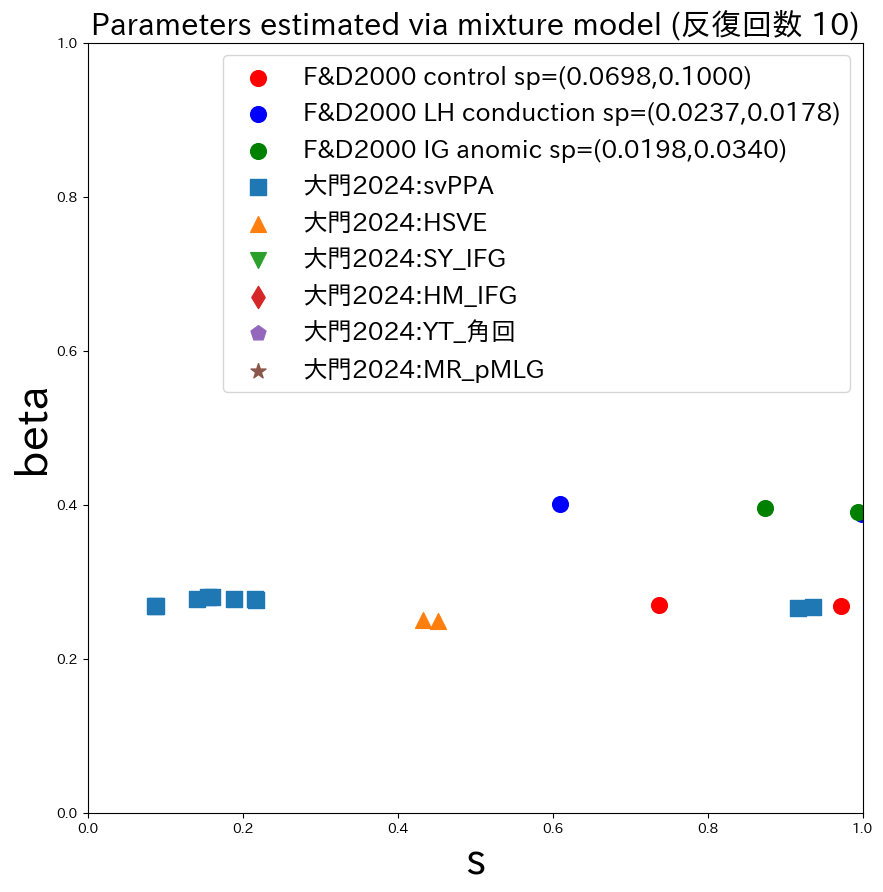

In [ ]:
Daimon_tags = ['svPPA', 'HSVE', 'SY_IFG', 'HM_IFG', 'YT_角回', 'MR_pMLG']
markers=['s', '^', 'v', 'd', 'p', '*']
C = []
for i, dai in enumerate(daimon_mixture_results):
    ii = i // reps
    beta, s, p, y_hat = dai
    C.append(np.array([s,beta]))
C = np.array(C)
print(f'C.shape:{C.shape}')

plt.figure(figsize=(10,10))
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('s', fontsize=32)
plt.ylabel('beta', fontsize=32)
plt.title('Parameters estimated via mixture model (反復回数 10)', fontsize=22)

for i in range(3):
    Dell_Z = Dell_C[i*reps:i*reps+reps]
    plt.scatter(Dell_Z[:,0], Dell_Z[:,1], color=dell_colors[i],label=dell_labels[i],s=128)

for i in range(6):
    #ii = i // 10
    Z = C[i*10:i*10+10,:]
    plt.scatter(Z[:,0], Z[:,1],label=f'大門2024:{Daimon_tags[i]}', marker=markers[i], s=128)


plt.legend(fontsize=18)
#plt.savefig('2025_0813mixture_plot.pdf')
plt.show()



# Foygel&Dell(2000) Table. 2 のシミュレーション実験

In [ ]:
%%time
FD2000_tab2 = {}
for pat, v in FoygelDell_tab2.items():
    others = 1 - np.array(v[:6]).sum()
    v = v[:6]+[others]
    FD2000_tab2[pat] = torch.Tensor(v)
    #FD2000_tab2[pat] = torch.Tensor(v/np.array(v).sum())
    print(f'{pat:32s}', FD2000_tab2[pat]) # np.array(v).sum(), v) #, np.array(v).sum())

#print(FD2000_tab2)

verbose=True
out_f = 'exp'
out_f = 'sigmoid'
out_f = 'mixture'
#out_f = 'None'
is_beta_param = True
lr = 1e-1
iter_max = 1 * 10 ** 3
reps = 1

daimon_mixture_results = []
for _teach in FD2000_tab2.values():
    print(f'_teach:{_teach}')
    for _ in range(reps):
        _model = Dell_modelX(Rs=Rs, Rp=Rp, out_f=out_f, is_beta_param=is_beta_param)
        #_model = Dell_model0(Rs=Rs, Rp=Rp)
        y_hat, [beta, s, p] = train_dell(target=_teach, model=_model, out_f=out_f, verbose=verbose, lr=lr, iter_max=iter_max)
        print(f'Finale, beta:{beta:.3f}, s:{s:.3f}, p:{p:.3f}, y_hat:{y_hat}')
        daimon_mixture_results.append((beta,s,p,y_hat))

W.B_Wernicke                     tensor([0.940, 0.020, 0.010, 0.010, 0.010, 0.000, 0.010])
T.T._Anomic                      tensor([0.930, 0.010, 0.010, 0.000, 0.020, 0.000, 0.030])
J.Fr._Wernicke                   tensor([0.920, 0.010, 0.010, 0.020, 0.020, 0.000, 0.020])
V.C._Anomic                      tensor([0.870, 0.020, 0.010, 0.030, 0.010, 0.000, 0.060])
L.B._Anomic                      tensor([0.820, 0.040, 0.020, 0.090, 0.010, 0.010, 0.010])
J.B._Conduction                  tensor([0.760, 0.060, 0.010, 0.050, 0.020, 0.010, 0.090])
J.L._Conduction                  tensor([0.760, 0.030, 0.010, 0.060, 0.030, 0.010, 0.100])
G.S._Wernicke                    tensor([0.700, 0.020, 0.060, 0.150, 0.010, 0.020, 0.040])
L.H._Conduction                  tensor([0.690, 0.030, 0.070, 0.150, 0.010, 0.020, 0.030])
J.G._Conduction                  tensor([0.550, 0.060, 0.080, 0.180, 0.040, 0.030, 0.060])
E.G._Anomic                      tensor([0.930, 0.030, 0.000, 0.010, 0.020, 0.000, 0.010])

# 奥平 (2012) データのシミュレーション

In [ ]:
import pandas as pd

HOME = os.environ['HOME']
oku2012_basedir = os.path.join(HOME, 'study/2025ccap')
oku2012_excel_fname = os.path.join(oku2012_basedir, '奥平2012_TLPA錯語分類_Dell用.xlsx')

oku2012_df = pd.read_excel(oku2012_excel_fname, sheet_name='Sheet3')
'''
このデータは奥平(2012)呼称における誤反応の分析から見た語彙処理， 神経心理学28；133-144 の表 1 および 表 1 続き
から計算したものである。表1続きの錯語等合計の値と表1の錯語等の割合を元にして反応総数を計算した。
その結果の反応総数の推定値は,全体反応の推定値(錯語等合計/錯語等％)は
[症例YH ①,YH ②,HF ①,HF ②,KS ①,KS ②,SS ①,SS ②,HT ①,HT ②,AH ①,AH ②,SA ①,SA ②,KI,SAK,NE,SM,WT,SHK,SH,KY,ITY,YM,MK,MS,TT,KK,INY]=
[340, 350, 229, 216, 710, 585, 439, 411, 254, 340, 341, 585, 267, 226, 364, 368, 327, 368, 218, 256, 204, 313, 276, 226, 388, 396, 700, 556, 414]
となった。この総反応数から,各錯語の種類 (意味性,形式性,混合性,無関連) の割合を計算した。
非単語については,(新造語＋中断・音断片)の値とした。
音韻性錯語は無視した。他に無反応・保続,及び, 迂言等も無視した。このため各症例ごとの総和が 1 以下である。
Foygel&Dell(2000) に合わせるためには, この 6 カテゴリーで総和が 1 となるような修正が必要となる。
このため,このセルの下方 _Okudaira2012_tab1 では総和が 1 となるような修正を行っている。
'''

oku2012_dict = oku2012_df.to_dict(orient='index')
Okudaira2012_tab1 = {}
key_list = ['正答', '意味性錯語', '形式性錯語', '混合性錯語', '無関連錯語', '非単語(音韻性)','その他(新造語,中断・音断片,保続,迂言等)']
for k, v in oku2012_dict.items():
    Okudaira2012_tab1[v['症例']] = []
    #print(v['症例'],end=" ")
    sum = 0
    for ky in key_list:
        Okudaira2012_tab1[v['症例']].append(float(v[ky]))
        sum += float(v[ky])
        #print(float(v[ky]), end=",")
    #print(sum)

print(Okudaira2012_tab1)
# Okudaira2012_tab1={
# #症例	正答	意味性錯語	形式性錯語	混合性錯語	無関連錯語	非単語(音韻性)	その他(新造語,中断・音断片,保続,迂言等)
# }
# for k, v in Okudaira2012_tab1.items():
#     print(k, np.array(v).sum())

# _Okudaira2012_tab1 = {k:np.array(v)/np.array(v).sum() for k, v in Okudaira2012_tab1.items()}
# for k, v in _Okudaira2012_tab1.items():
#     print(k, v, v.sum())


In [ ]:
Oku2012[:3]

In [ ]:
Oku2012 = []
for k, v in Okudaira2012_tab1.items():
#for k, v in _Okudaira2012_tab1.items():
    _d = torch.Tensor(v[:7])
    _d = _d/_d.sum()
    Oku2012.append((_d, k))

#print(Oku2012)
for pat in Oku2012:
    print(pat)

n_reps = 2
okudaira_results = train_all_conditions(
    n_reps=n_reps,
    data_condtions=Oku2012[-3:],
    model_out_fs=['mixture'], # ['sigmoid'], # 'mixture'], # 'exp'],
    beta_params=[True],
)

# for patient, teacher in Okudaira2012_tab1.items():
#     teacher = np.array(teacher[:6])
#     teacher = np.array(teacher[:6]) / teacher.sum()
#     teacher = torch.tensor(teacher)
#     pred, [beta, s, p] = train_dell(teacher, Dell_model0)
#     print('-' * 73)
#     print(f'患者名:{patient}')
#     print('                ', list(phonology))
#     print('実データ:        ', teacher.detach().numpy())
#     print('シミュレーション: ', pred)
#     print(f'ベータ:{1/beta:.3f} s:{s:.3f} p:{p:.3f}')
#     draw_dell_graph(teacher,pred, width_inches=7,height_inches=3, fontsize=14,
#                     alabel='患者イニシャル:{0}'.format(patient), blabel='シミュレーション結果'
#                    )

In [ ]:
sp = torch.tensor([0.68, 0.95])
for x in sp:
    #print(x, torch.exp(sp)) # , torch.ex(sp).sum())
    print(np.exp(x)/np.exp(sp).sum(), torch.sigmoid(x))

In [ ]:
class Dell_modelX2(nn.Module):
    """Dell model 普及機
    s, p を sigmoid(), または exp() に変換して強制的に 0 < s, p, または 0 < s, p < 1 に変換する
    """
    def __init__(self,
                 Rs:torch.Tensor,
                 Rp:torch.Tensor,
                 out_f:str='None',  # ['none', 'exp', 'sigmoid'],
                 model_name:str='WholeBrain',
                 is_beta_param:bool=True
                ):
        super().__init__()
        self.Rs = Rs      #意味層と語彙層との間の結合係数
        self.Rp = Rp      #語彙層と音韻層との間の結合係数
        # self.theta_s = nn.Parameter(torch.randn(1))  #Dell の s パラメータ
        # self.theta_p = nn.Parameter(torch.randn(1))  #Dell の p パラメータ

        self.linS = torch.nn.Linear(in_features=Rs.shape[0]+Rs.shape[1],
                                    out_features=1, bias=True)
        self.linP = torch.nn.Linear(in_features=Rp.shape[0]+Rp.shape[1],
                                    out_features=1, bias=True)

        # if model_name == 'WholeBrain':
        #     self.WholeBrain = torch.nn.Linear(
        #         in_features=Rs.numel()+Rp.numel(), out_features=2, bias=True)

        self.out_f_name = 'None'
        self.is_beta_param = is_beta_param

        if out_f == 'None':
            self.out_fname = 'None'
            self.theta_s = nn.Parameter(torch.randn(1))  #Dell の s パラメータ
            self.theta_p = nn.Parameter(torch.randn(1))  #Dell の p パラメータ
        elif out_f == 'exp':  # 初号機に相当
            self.out_fname = 'exp'
            self.out_f = torch.exp
        elif out_f == 'sigmoid':
            self.out_fname = 'sigmoid'
            self.out_f = torch.sigmoid
        elif out_f == 'mixture':
            self.out_fname = 'exp'
            self.out_f = torch.exp
        else:
            raise ValueError(f'不正な出力層の活性化関数: {out_f}')

        sem = np.zeros(Rs.shape[0])
        sem[0] =1
        self.sem = torch.nn.Parameter(torch.Tensor(sem))

        self.lex = torch.nn.Parameter(torch.Tensor(np.zeros(Rs.shape[0])))
        self.pho = torch.nn.Parameter(torch.Tensor(np.zeros(Rp.shape[0])))
        #self.sem = torch.nn.Parameter(torch.zeros(self.Rs.shape[0])) #.requires_grad_(True)
        #self.sem[0] = 1
        #self.sem.requires_grad_(True)
        #self.lex = torch.nn.Parameter(torch.zeros(self.Rs.shape[0]).requires_grad_(True))
        #self.pho = torch.nn.Parameter(torch.zeros(self.Rp.shape[0]).requires_grad_(True))

        # self.theta_s = self.linS(torch.concat((self.sem, self.lex)))
        # self.theta_p = self.linP(torch.concat((self.sel, self.pho)))

        # #語彙層のバイアス項 Dell のオリジナルモデルには存在しない
        # self.bias_sem = nn.Parameter(torch.zeros(self.Rs.shape[0]))

        # #語彙層のバイアス項 Dell のオリジナルモデルには存在しない
        # self.bias_lex = nn.Parameter(torch.zeros(self.Rs.shape[0]))

        # #音韻層のバイアス項 Dell のオリジナルモデルには存在しない
        # self.bias_pho = nn.Parameter(torch.zeros(self.Rp.shape[0]))

        self.beta = nn.Parameter(torch.tensor([1.]))  #ソフトマックス関数の温度パラメータ
        self.a = nn.Tanh()                            #ハイパータンジェント関数を活性化関数として採用

    def forward(self):
        """前向きの処理"""

        theta_s = self.linS(torch.concat((self.sem, self.lex)))
        theta_p = self.linP(torch.concat((self.lex, self.pho)))
        if not self.out_fname == 'None':
            theta_s = theta_s
            theta_p = theta_p
        elif self.out_fname == 'exp':
            theta_s = torch.exp(theta_s)
            theta_p = torch.exp(theta_p)
        elif self.out_fname == 'sigmoid':
            theta_s = torch.sigmoid(theta_s)
            theta_p = torhc.sigmoid(theta_p)
        elif self.out_fname == 'mixture':
            expsum = torch.exp(theta_s) + torch.exp(theta_p)
            theta_s = torch.exp(theta_s) / expsum
            theta_p = torch.exp(theta_p) / expsum
            theta_p = 1.0 - theta_s

        self.theta_s = theta_s
        self.theta_p = theta_p
        self.sem = self.a(self.lex @ (self.Rs * theta_s))

        # 語彙層は意味層と音韻層との両者から入力を受け取るので,上杉さんの指摘により変更 2025_0723
        self.lex = self.a(sem @ (self.Rs * theta_s + self.Rp * theta_p))
        self.pho = self.a(lex @ (self.Rp * theta_p) )

        # self.sem = self.a(self.lex @ self.Rs) * theta_s

        # # 語彙層は意味層と音韻層との両者から入力を受け取るので,上杉さんの指摘により変更 2025_0723
        # self.lex = self.a(self.sem @ (self.Rs * theta_s + self.Rp * theta_p))
        # self.pho = self.a(self.lex @ (self.Rp * theta_p) ) # + self.bias_pho)

        self.pho = my_softmax(self.pho, beta=self.beta, is_beta_param=self.is_beta_param)
        return self.pho


In [ ]:
_model = Dell_modelX2(Rp=Rp, Rs=Rs)
#_model = Dell_modelX(Rp=Rp, Rs=Rs)
_model.eval()

out_f='sigmoid'
is_beta_param=True
_teach = Dell_control
_model= Dell_modelX(Rs=Rs, Rp=Rp,out_f=out_f,is_beta_param=is_beta_param)
_model= Dell_modelX2(Rs=Rs, Rp=Rp,out_f=out_f,is_beta_param=is_beta_param)

y_hat, [beta, s, p] = train_dell(
    _teach, model=_model, out_f=out_f)

print(f'y_hat:{y_hat}, _teach:{_teach}, beta:{beta}, s:{s}, p:{p}')

In [ ]:
(_model.sem @ torch.tensor(Ws,dtype=torch.float32)).size()
(torch.tensor(Ws,dtype=torch.float32).T @ _model.sem).size()
#Ws.shape

In [ ]:
#lex = torch.zeros(Rs.shape[0],dtype=torch.float32).requires_grad_(True)
#A = torch.zeros(3).requires_grad_(True)
A = np.zeros(3)
A[0] = 1

A = torch.nn.Parameter(torch.Tensor(A))
type(_model.lex)
type(_model.lex @ _model.Rs)
#_model.Rs.size(), _model.lex.size()
[x for x in _model.named_parameters()]

In [ ]:
#help(torch.nn.Parameter)
type(Rs)
Rs.requires_grad